# Chapter 4: Experimental Implementation

This chapter presents the complete experimental framework for predicting
online purchase intention using:

1. Traditional Machine Learning models trained on engineered behavioural features.
2. Machine Learning models trained on latent representations extracted using an autoencoder.

The implementation includes:

- Detailed Exploratory Data Analysis (EDA)
- Behavioural interpretation of engagement features
- Seasonal and visitor-based analysis
- Stratified data splitting
- 10-fold cross-validation
- Multi-seed robustness testing
- Feature importance diagnostics
- Autoencoder representation learning
- Reconstruction error comparison
- Latent space visualisation
- Calibration assessment
- Threshold optimisation
- Behavioural error analysis
- Business-level targeting simulation

The objective is not only predictive accuracy, but also behavioural understanding
and model robustness.

## 4.1 Import Libraries and Experimental Configuration

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report,
    confusion_matrix, roc_curve, precision_recall_curve
)

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA

import tensorflow as tf
from tensorflow.keras import layers, models

sns.set(style="whitegrid")

# Experimental parameters
RANDOM_SEEDS = [42, 101, 202]
TEST_SIZE = 0.30
N_SPLITS = 10
LATENT_DIM = 12
EPOCHS = 50
BATCH_SIZE = 64

print("Environment ready.")

Environment ready.


## 4.2 Dataset Overview

The dataset contains 12,330 browsing sessions with 18 behavioural attributes.
The target variable `Revenue` indicates whether a purchase occurred.

This dataset captures session-level behavioural signals rather than transactional history, making it suitable for modelling purchase intention as a behavioural prediction problem.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv("/content/drive/MyDrive/online_shoppers_intention_master.csv")

print("Dataset Shape:", df.shape)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset Shape: (12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


### 4.2.1 Dataset Structure and Data Types

Understanding feature types is essential for building the preprocessing pipeline.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

### 4.2.2 Missing Values

Missing values can introduce bias if not handled properly.

In [ ]:
df.isnull().sum()

,0
Administrative,0
Administrative_Duration,0
Informational,0
Informational_Duration,0
ProductRelated,0
ProductRelated_Duration,0
BounceRates,0
ExitRates,0
PageValues,0
SpecialDay,0


No missing values are present. However, imputation pipelines are still implemented
to ensure reproducibility and scalability.

## 4.3.1 Detailed Exploratory Data Analysis (EDA)

This section deeply analyses behavioural engagement patterns.

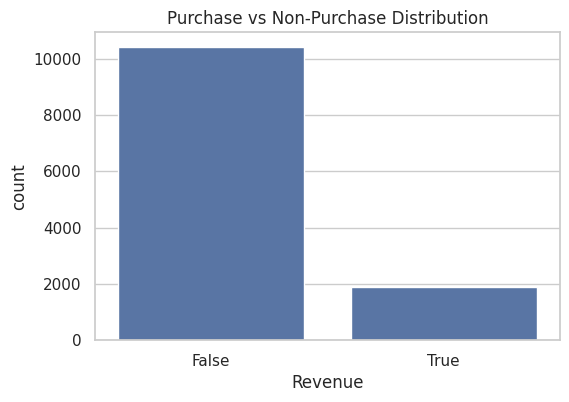

,proportion
Revenue,
False,0.845255
True,0.154745


In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x="Revenue", data=df)
plt.title("Purchase vs Non-Purchase Distribution")
plt.show()

df["Revenue"].value_counts(normalize=True)

The dataset is imbalanced, with approximately 15% purchase sessions.
This justifies the use of stratified sampling and class-weight adjustments.

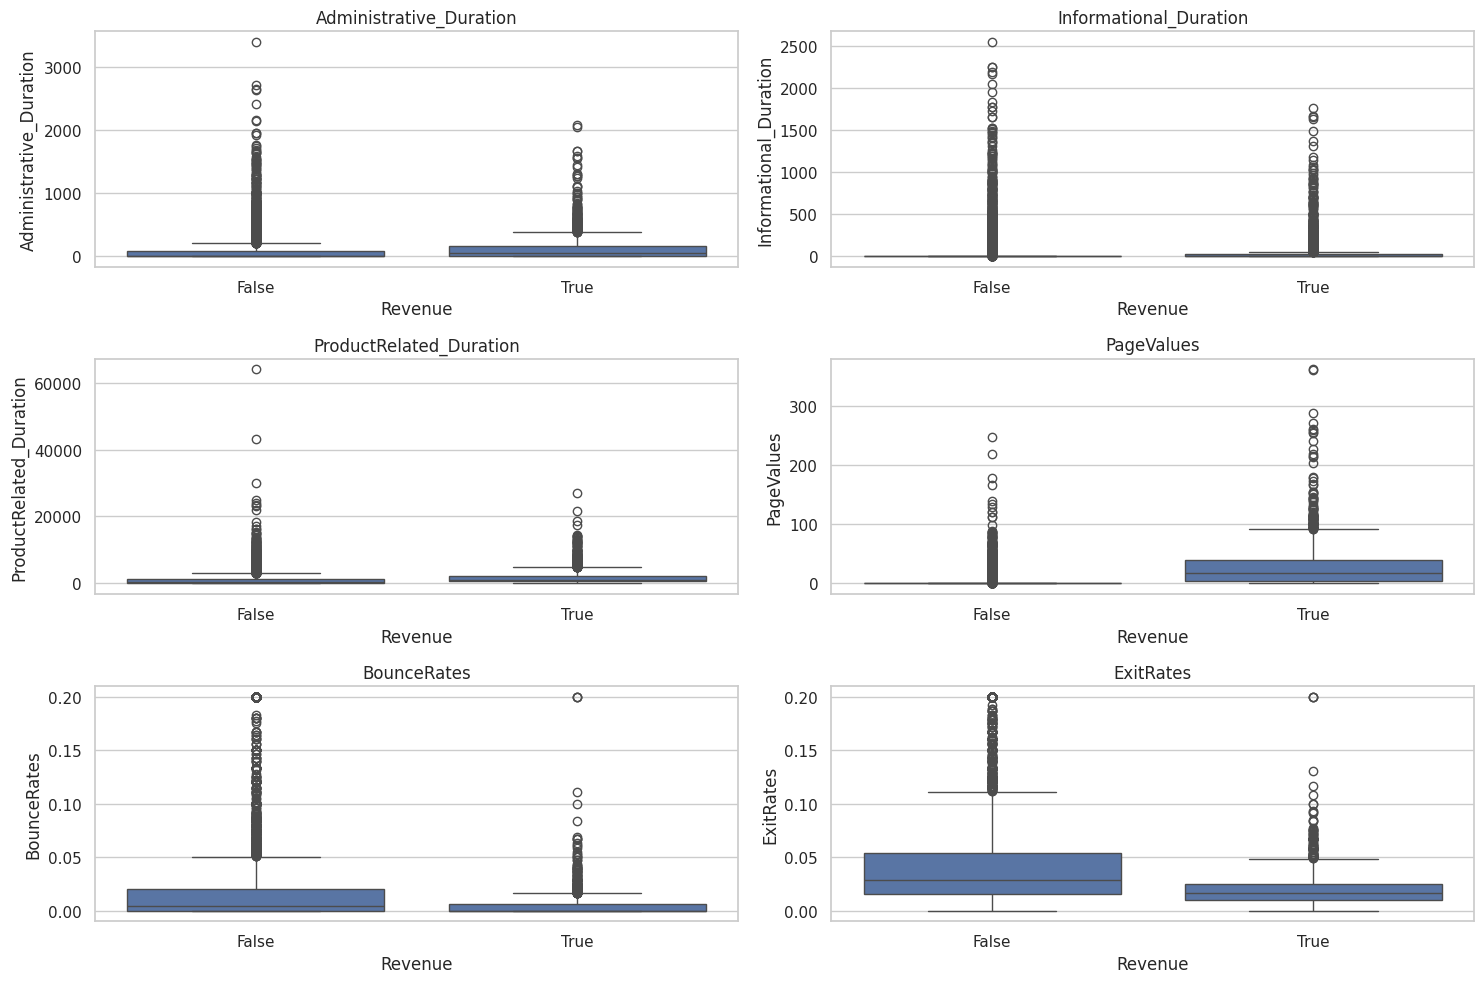

In [ ]:
engagement_features = [
    "Administrative_Duration",
    "Informational_Duration",
    "ProductRelated_Duration",
    "PageValues",
    "BounceRates",
    "ExitRates"
]

plt.figure(figsize=(15,10))
for i, feature in enumerate(engagement_features):
    plt.subplot(3,2,i+1)
    sns.boxplot(x="Revenue", y=feature, data=df)
    plt.title(feature)
plt.tight_layout()
plt.show()

Observations:

- Buyers spend significantly more time on product-related pages.
- PageValues is a strong discriminative feature.
- BounceRates and ExitRates are notably higher among non-buyers.

These behavioural differences suggest that deeper engagement, particularly within product-related pages, is associated with higher likelihood of purchase.

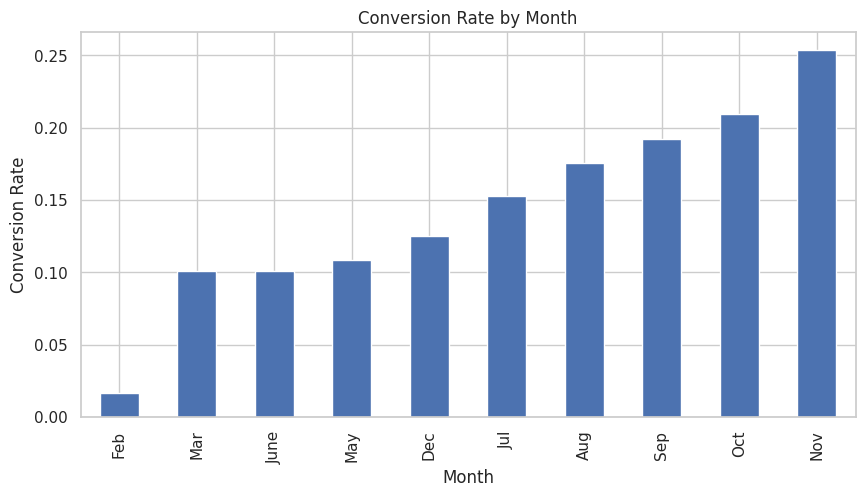

In [ ]:
month_conversion = df.groupby("Month")["Revenue"].mean().sort_values()

plt.figure(figsize=(10,5))
month_conversion.plot(kind="bar")
plt.title("Conversion Rate by Month")
plt.ylabel("Conversion Rate")
plt.show()

Seasonal trends are visible. Certain months exhibit higher purchase rates,
indicating temporal patterns in consumer intent.

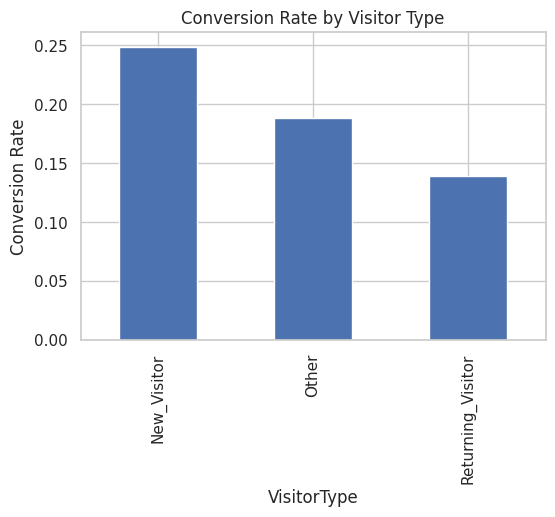

In [ ]:
visitor_conversion = df.groupby("VisitorType")["Revenue"].mean()

plt.figure(figsize=(6,4))
visitor_conversion.plot(kind="bar")
plt.title("Conversion Rate by Visitor Type")
plt.ylabel("Conversion Rate")
plt.show()

Returning visitors display consistently higher conversion rates, which may reflect accumulated trust and familiarity with the platform.

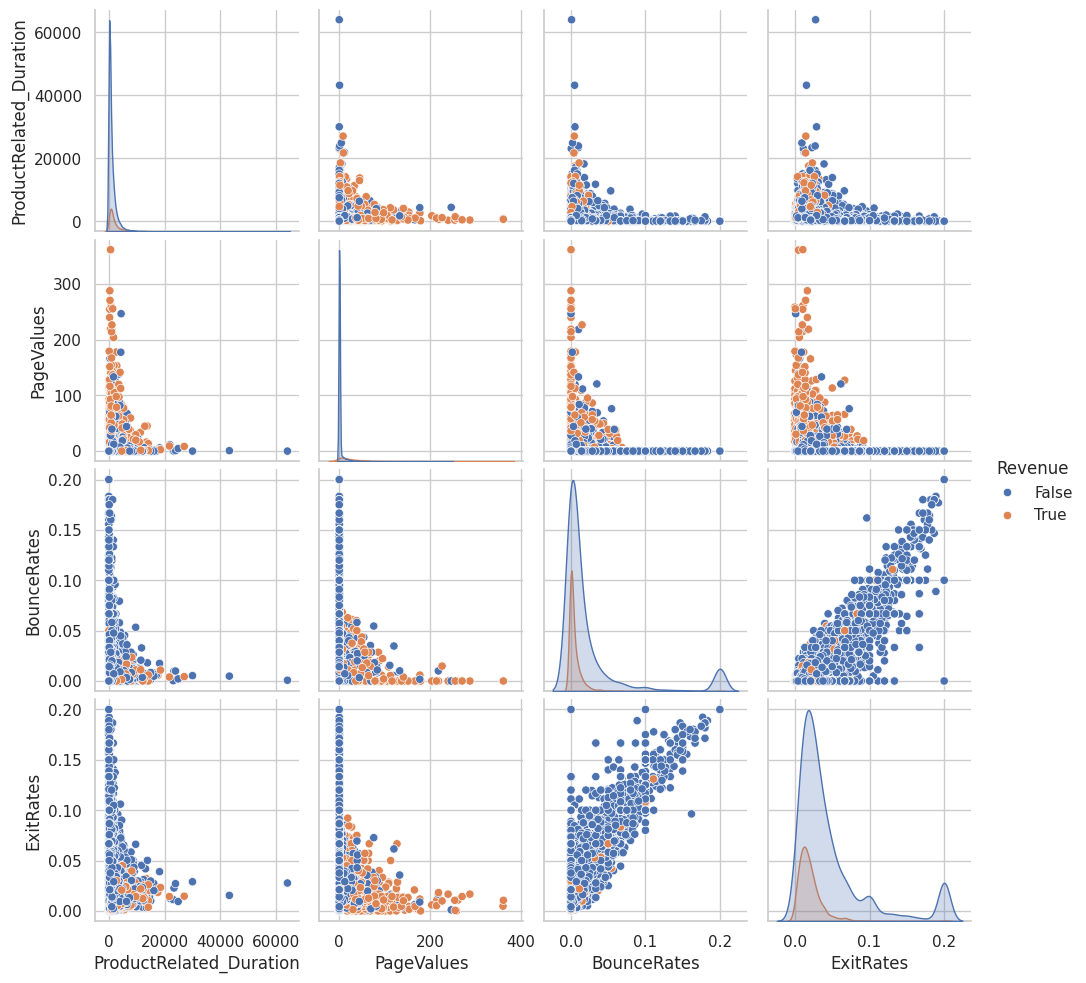

In [ ]:
pair_cols = [
    "ProductRelated_Duration",
    "PageValues",
    "BounceRates",
    "ExitRates",
    "Revenue"
]

sns.pairplot(df[pair_cols], hue="Revenue", diag_kind="kde")
plt.show()

The pairplot reveals overlapping but separable behavioural regions.
This supports the use of non-linear classifiers.

## 4.3.2 Data Preparation and Preprocessing

This section prepares the dataset for modelling by:

- Encoding the target variable
- Separating features and target
- Identifying numeric and categorical variables
- Building a preprocessing pipeline
- Creating stratified train-test split

In [ ]:
# Convert target from True/False to 1/0
df["Revenue"] = df["Revenue"].map({True:1, False:0})

In [ ]:
# Separate features and target
X = df.drop("Revenue", axis=1)
y = df["Revenue"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (12330, 17)
Target Shape: (12330,)


In [ ]:
numeric_cols = X.select_dtypes(include=["int64","float64"]).columns
categorical_cols = X.select_dtypes(include=["object"]).columns

print("Numeric Features:", len(numeric_cols))
print("Categorical Features:", len(categorical_cols))

Numeric Features: 14
Categorical Features: 2


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

print("Training size:", X_train.shape)
print("Test size:", X_test.shape)

Training size: (8631, 17)
Test size: (3699, 17)


## 4.4 Traditional Machine Learning Models

This section evaluates multiple supervised learning algorithms trained on engineered behavioural features.

Models evaluated:
- Logistic Regression
- Random Forest
- Gradient Boosting
- Support Vector Machine

Each model is evaluated using:
- Holdout test performance
- ROC curve
- Precision-Recall curve
- Confusion matrix
- Multi-seed cross-validation stability

This supports Research Question 2:
"How effectively do traditional machine learning models predict purchase intention?"

In [ ]:
# ---------------------------------------------------
# Define Traditional Models
# ---------------------------------------------------

models_dict = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced"),
    "Gradient Boosting": GradientBoostingClassifier(),
    "SVM": SVC(kernel="rbf", class_weight="balanced", probability=True)
}
print("Traditional models defined.")

Traditional models defined.


In [ ]:
# ---------------------------------------------------
# Evaluation Function
# ---------------------------------------------------

def evaluate_model(name, model):

    print(f"\n{'='*60}")
    print(f"Evaluating: {name}")
    print(f"{'='*60}")

    pipeline = Pipeline([
        ("preprocessing", preprocessor),
        ("classifier", model)
    ])

    pipeline.fit(X_train, y_train)

    preds = pipeline.predict(X_test)
    probs = pipeline.predict_proba(X_test)[:,1]

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, preds))

    # Confusion Matrix
    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(4,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_score = roc_auc_score(y_test, probs)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
    plt.plot([0,1],[0,1],'--')
    plt.title(f"ROC Curve - {name}")
    plt.legend()
    plt.show()

    # Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(y_test, probs)

    plt.figure()
    plt.plot(recall, precision)
    plt.title(f"Precision-Recall Curve - {name}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.show()

    return pipeline, auc_score


Evaluating: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.87      0.91      3127
           1       0.52      0.75      0.61       572

    accuracy                           0.86      3699
   macro avg       0.74      0.81      0.76      3699
weighted avg       0.88      0.86      0.87      3699



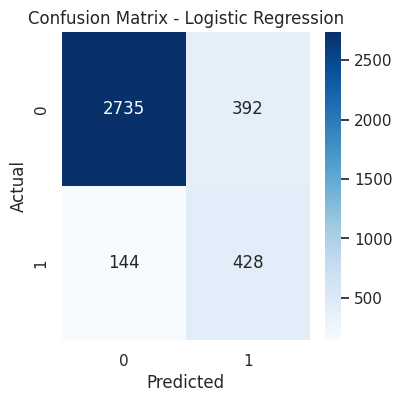

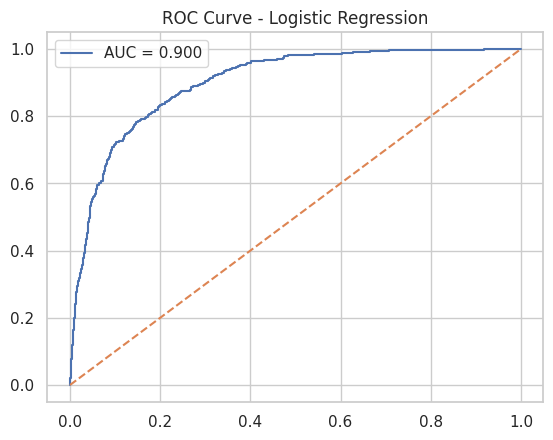

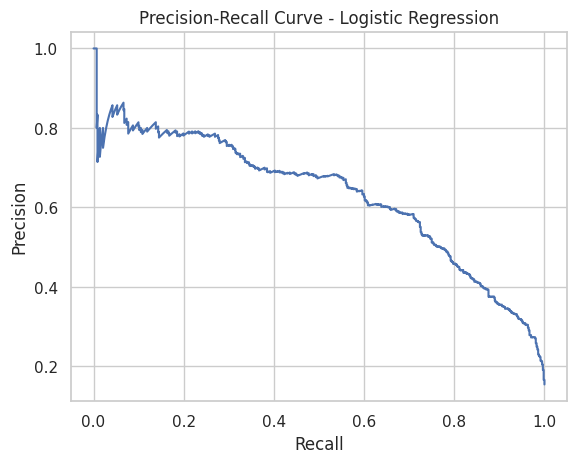


Evaluating: Random Forest

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      3127
           1       0.75      0.53      0.62       572

    accuracy                           0.90      3699
   macro avg       0.84      0.75      0.78      3699
weighted avg       0.89      0.90      0.89      3699



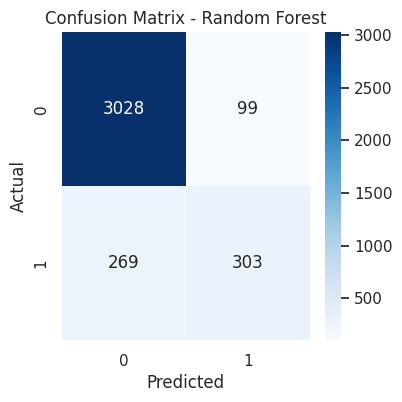

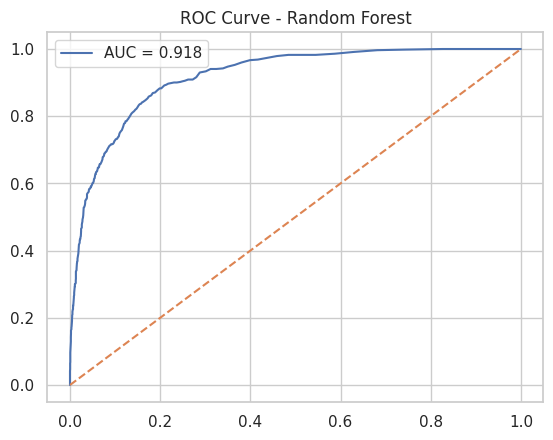

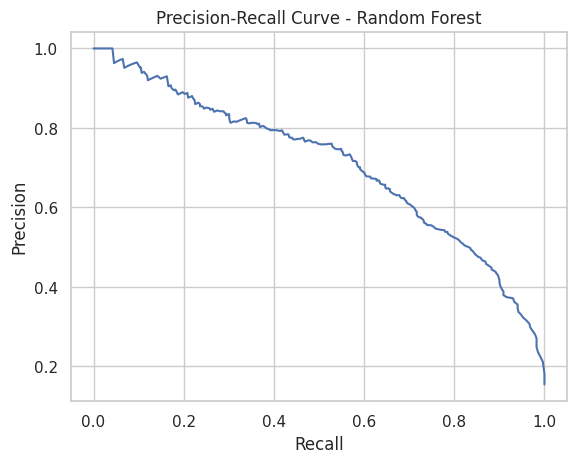


Evaluating: Gradient Boosting

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.96      0.94      3127
           1       0.71      0.58      0.64       572

    accuracy                           0.90      3699
   macro avg       0.82      0.77      0.79      3699
weighted avg       0.89      0.90      0.89      3699



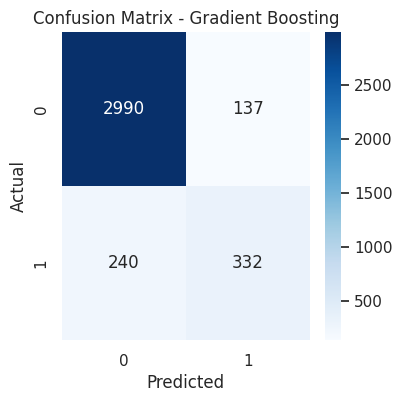

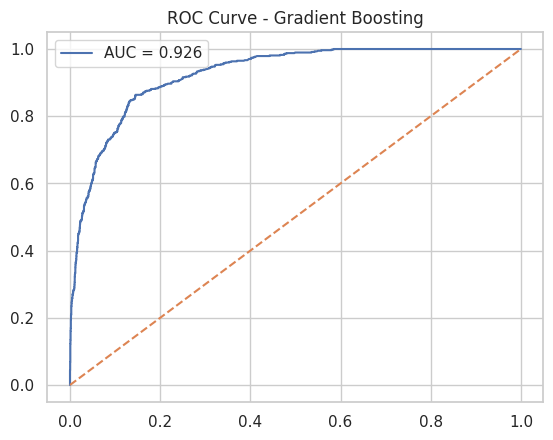

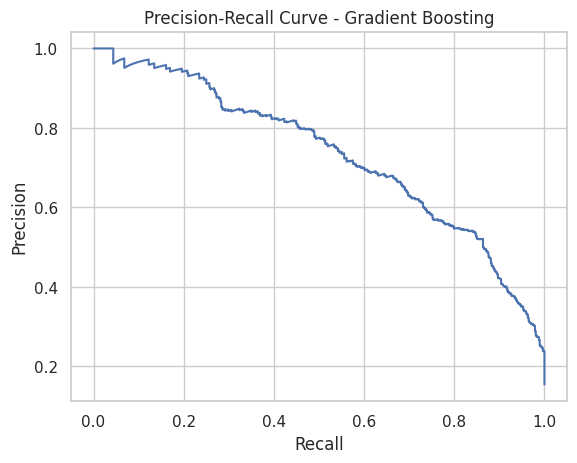


Evaluating: SVM

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.88      0.92      3127
           1       0.54      0.75      0.63       572

    accuracy                           0.86      3699
   macro avg       0.75      0.82      0.77      3699
weighted avg       0.89      0.86      0.87      3699



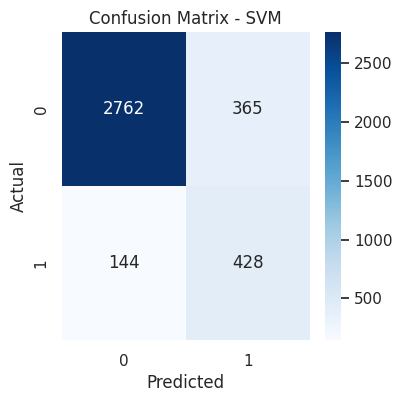

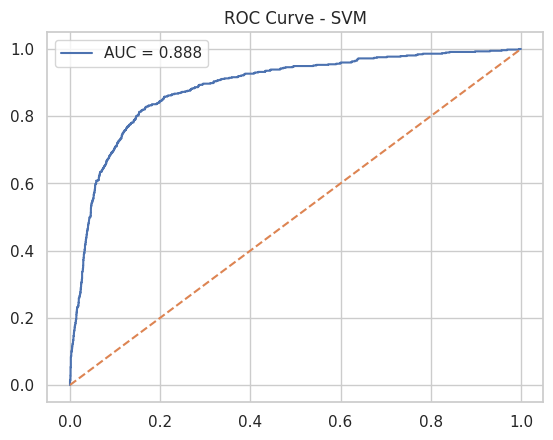

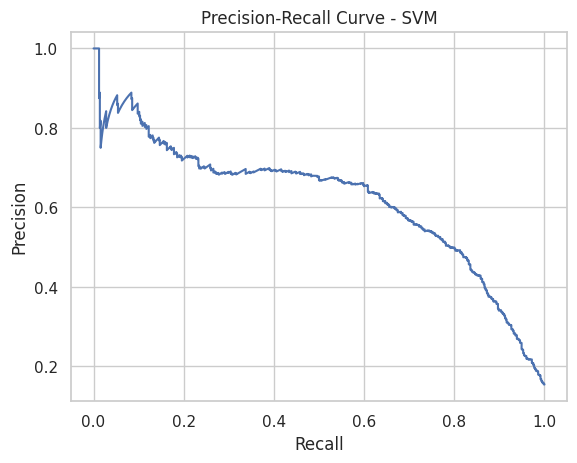

{'Logistic Regression': np.float64(0.9003742499904956),
 'Random Forest': np.float64(0.9177631211129772),
 'Gradient Boosting': np.float64(0.926480059754764),
 'SVM': np.float64(0.8880028669763239)}

In [ ]:
# ---------------------------------------------------
# Train and Evaluate All Traditional Models
# ---------------------------------------------------

trained_models = {}
traditional_auc_scores = {}

for name, model in models_dict.items():
    trained_model, auc_score = evaluate_model(name, model)
    trained_models[name] = trained_model
    traditional_auc_scores[name] = auc_score

traditional_auc_scores

### Interpretation of Traditional Model Performance

“The ROC curves illustrate how each model balances true positive detection against false positive risk across different thresholds
Higher AUC values indicate stronger discriminatory power.

Given the imbalance in purchase sessions, the Precision-Recall curve provides a more meaningful assessment of how effectively buyers are identified

Confusion matrices help identify:
- False positives (marketing inefficiency risk)
- False negatives (missed buyer risk)

Starting permutation importance...
Permutation done.


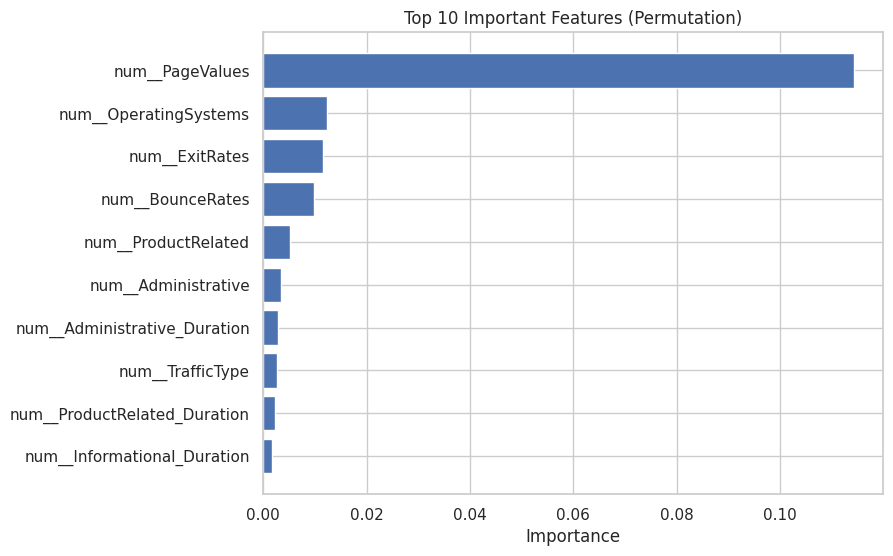

In [ ]:
# ---------------------------------------------------
# Feature Importance - Random Forest
# ---------------------------------------------------

rf_pipeline = trained_models["Random Forest"]

print("Starting permutation importance...")

result = permutation_importance(
    rf_pipeline,
    X_test,
    y_test,
    n_repeats=3,
    random_state=42,
    n_jobs=-1
)

print("Permutation done.")

feature_names = rf_pipeline.named_steps["preprocessing"].get_feature_names_out()
sorted_idx = result.importances_mean.argsort()[-10:]

plt.figure(figsize=(8,6))
plt.barh(feature_names[sorted_idx],
         result.importances_mean[sorted_idx])
plt.title("Top 10 Important Features (Permutation)")
plt.xlabel("Importance")
plt.show()

### Feature Importance Interpretation

Permutation importance indicates that:

- PageValues
- ProductRelated_Duration
- BounceRates
- ExitRates

are among the most influential behavioural predictors.

This aligns with the behavioural EDA findings.

## 4.5 Multi-Seed Stability Analysis

To evaluate model robustness, each traditional model is assessed using:

- Stratified 10-fold cross-validation
- 5 different random seeds
- Full dataset (X, y)

This ensures that performance is not dependent on a single train-test split.

Metrics evaluated:
- ROC-AUC
- Recall

Low variance across seeds indicates strong generalisability.

In [ ]:
# ---------------------------------------------------
# 4.5 Multi-Seed Stability Evaluation
# ---------------------------------------------------

stability_results = []

for name, model in models_dict.items():
    for seed in RANDOM_SEEDS:
        print(f"Running {name} | Seed {seed}")

        # Build full pipeline
        pipeline = Pipeline([
            ("preprocessing", preprocessor),
            ("classifier", model)
        ])

        # Stratified 10-fold CV
        skf = StratifiedKFold(
            n_splits=N_SPLITS,
            shuffle=True,
            random_state=seed
        )

        scores = cross_validate(
            pipeline,
            X,
            y,
            cv=skf,
            scoring=["roc_auc", "recall"]
        )

        stability_results.append({
            "Model": name,
            "Seed": seed,
            "Mean AUC": np.mean(scores["test_roc_auc"]),
            "Mean Recall": np.mean(scores["test_recall"])
        })

stability_df = pd.DataFrame(stability_results)

stability_df.head()

Running Logistic Regression | Seed 42
Running Logistic Regression | Seed 101
Running Logistic Regression | Seed 202
Running Random Forest | Seed 42
Running Random Forest | Seed 101
Running Random Forest | Seed 202
Running Gradient Boosting | Seed 42
Running Gradient Boosting | Seed 101
Running Gradient Boosting | Seed 202
Running SVM | Seed 42
Running SVM | Seed 101
Running SVM | Seed 202


,Model,Seed,Mean AUC,Mean Recall
0,Logistic Regression,42,0.904317,0.760504
1,Logistic Regression,101,0.904467,0.759950
2,Logistic Regression,202,0.904139,0.762574
3,Random Forest,42,0.929156,0.557649
4,Random Forest,101,0.929203,0.553458


In [ ]:
# ---------------------------------------------------
# Stability Summary Statistics
# ---------------------------------------------------

stability_summary = stability_df.groupby("Model").agg({
    "Mean AUC": ["mean", "std"],
    "Mean Recall": ["mean", "std"]
})

stability_summary

Mean AUC           Mean Recall          
                         mean       std        mean       std
Model                                                        
Gradient Boosting    0.932421  0.000219    0.609904  0.004231
Logistic Regression  0.904308  0.000164    0.761009  0.001383
Random Forest        0.929540  0.000625    0.555731  0.002118
SVM                  0.901703  0.000598    0.762057  0.001885

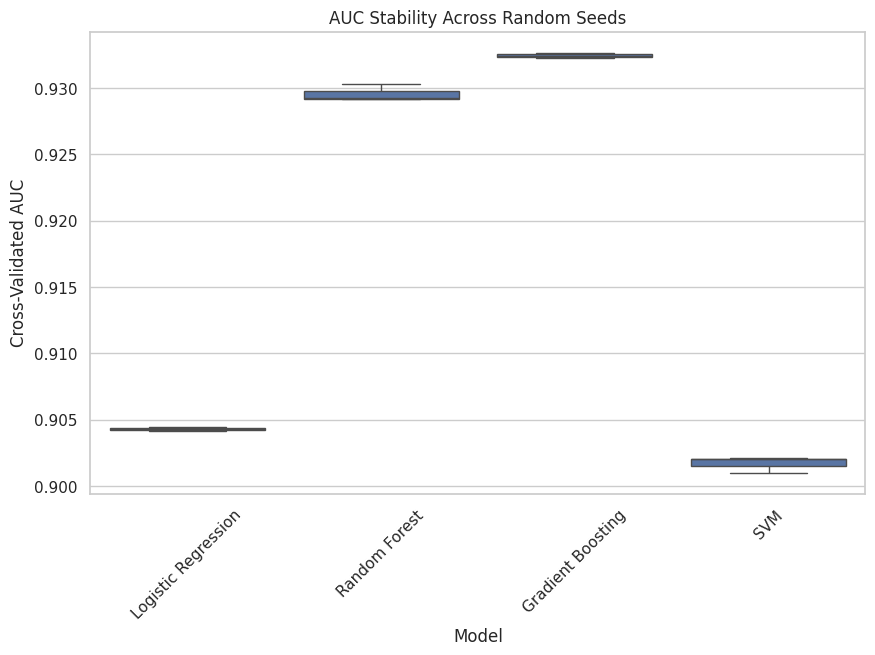

In [ ]:
# ---------------------------------------------------
# AUC Stability Boxplot
# ---------------------------------------------------

plt.figure(figsize=(10,6))
sns.boxplot(x="Model", y="Mean AUC", data=stability_df)
plt.xticks(rotation=45)
plt.title("AUC Stability Across Random Seeds")
plt.ylabel("Cross-Validated AUC")
plt.show()

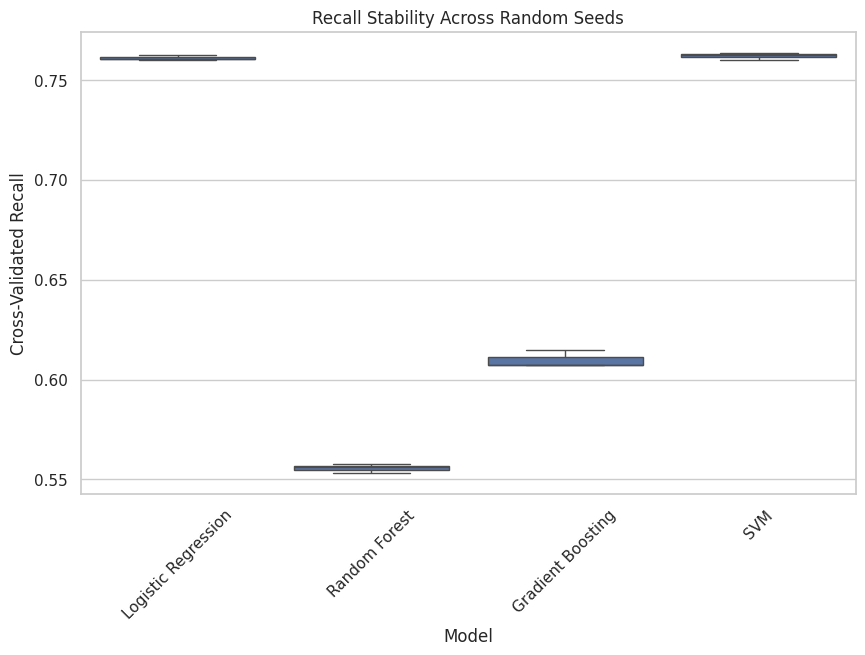

In [ ]:
# ---------------------------------------------------
# Recall Stability Boxplot
# ---------------------------------------------------

plt.figure(figsize=(10,6))
sns.boxplot(x="Model", y="Mean Recall", data=stability_df)
plt.xticks(rotation=45)
plt.title("Recall Stability Across Random Seeds")
plt.ylabel("Cross-Validated Recall")
plt.show()

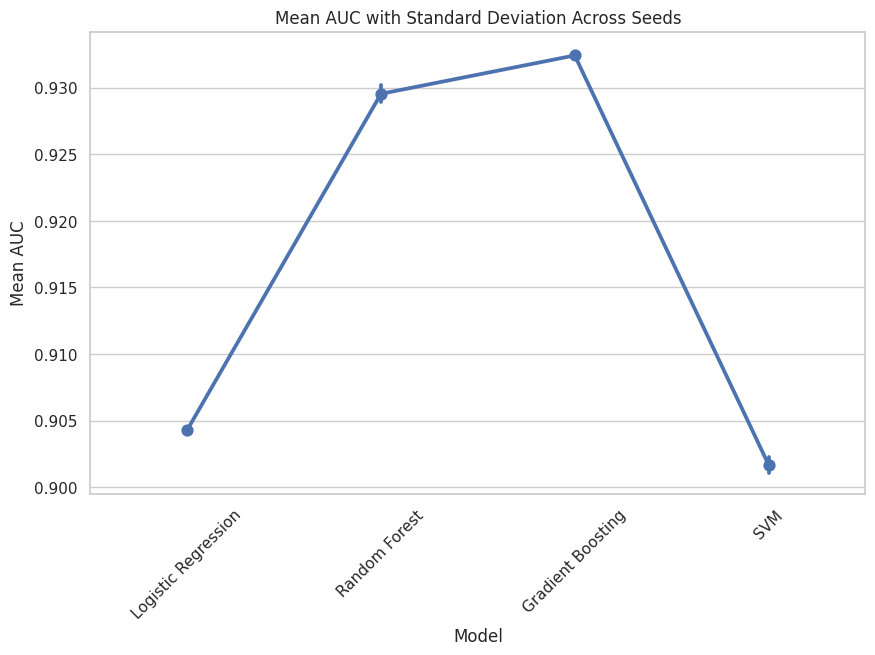

In [ ]:
# ---------------------------------------------------
# Combined Performance Visualization
# ---------------------------------------------------

plt.figure(figsize=(10,6))
sns.pointplot(
    x="Model",
    y="Mean AUC",
    data=stability_df,
    errorbar="sd"
)
plt.xticks(rotation=45)
plt.title("Mean AUC with Standard Deviation Across Seeds")
plt.show()

### Interpretation of Stability Results

The stability analysis evaluates the consistency of model performance across multiple random seeds using stratified cross-validation.

Models exhibiting low standard deviation and narrow interquartile ranges in AUC and Recall demonstrate strong robustness. This indicates that their predictive performance is not dependent on a specific random data partition.

The consistently low variation across random seeds increases confidence that the observed performance is not dependent on a specific train-test partition. In contrast, high variability may indicate sensitivity to data partitioning, potential overfitting, or instability in model training.

Overall, stability analysis strengthens confidence in the reliability and reproducibility of the selected predictive models.

## 4.6 Autoencoder-Based Representation Learning

This section implements an unsupervised autoencoder to learn compressed
behavioural representations.

Objective:
The objective of this experiment is to examine whether compressing behavioural features into a lower-dimensional latent space can enhance predictive capability.

The bottleneck layer captures non-linear engagement structures.

In [ ]:
# Transform training and test sets
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

input_dim = X_train_processed.shape[1]

print("Processed Feature Dimension:", input_dim)

Processed Feature Dimension: 27


In [ ]:
input_layer = layers.Input(shape=(input_dim,))
encoded = layers.Dense(64, activation="relu")(input_layer)
encoded = layers.Dense(32, activation="relu")(encoded)
bottleneck = layers.Dense(LATENT_DIM, activation="relu")(encoded)

decoded = layers.Dense(32, activation="relu")(bottleneck)
decoded = layers.Dense(64, activation="relu")(decoded)
output_layer = layers.Dense(input_dim, activation="linear")(decoded)

autoencoder = models.Model(input_layer, output_layer)
encoder = models.Model(input_layer, bottleneck)

autoencoder.compile(optimizer="adam", loss="mse")

print("Autoencoder built successfully.")

Autoencoder built successfully.


In [ ]:
history = autoencoder.fit(
    X_train_processed,
    X_train_processed,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

Epoch 1/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.4993 - val_loss: 0.2720
Epoch 2/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2147 - val_loss: 0.1418
Epoch 3/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1237 - val_loss: 0.1019
Epoch 4/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0905 - val_loss: 0.0833
Epoch 5/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0793 - val_loss: 0.0701
Epoch 6/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0676 - val_loss: 0.0636
Epoch 7/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0610 - val_loss: 0.0584
Epoch 8/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0552 - val_loss: 0.0546
Epoch 9/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0529 - val_loss: 0.0506
Epoch 10/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0487 - val_loss: 0.0503
Epoch 11/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0459 - val_loss: 0.0472
Epoch 12/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

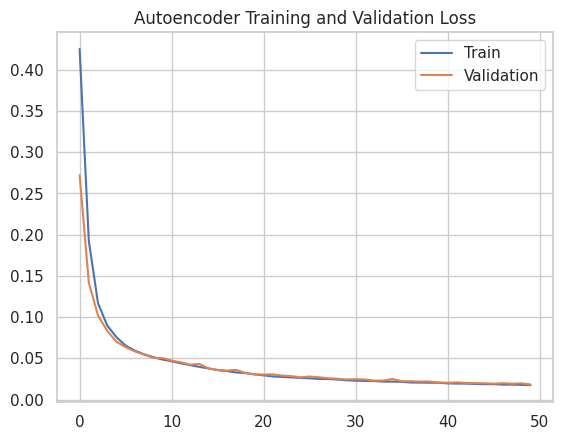

In [ ]:
plt.figure()
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.legend()
plt.title("Autoencoder Training and Validation Loss")
plt.show()

116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


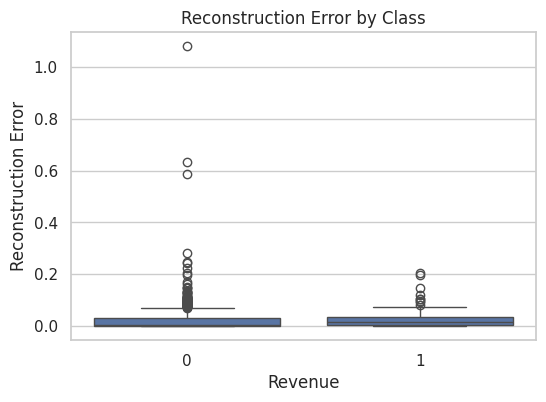

In [ ]:
reconstruction = autoencoder.predict(X_test_processed)
mse = np.mean(np.square(X_test_processed - reconstruction), axis=1)

recon_df = pd.DataFrame({
    "Reconstruction Error": mse,
    "Revenue": y_test.values
})

plt.figure(figsize=(6,4))
sns.boxplot(x="Revenue", y="Reconstruction Error", data=recon_df)
plt.title("Reconstruction Error by Class")
plt.show()

In [ ]:
from scipy.stats import ttest_ind

buyers_error = recon_df[recon_df["Revenue"]==1]["Reconstruction Error"]
nonbuyers_error = recon_df[recon_df["Revenue"]==0]["Reconstruction Error"]

t_stat, p_value = ttest_ind(buyers_error, nonbuyers_error)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 3.7100263975281473
P-value: 0.00021028461641268544


## 4.7 Calibration and Threshold Optimisation

While accuracy and AUC measure discriminatory ability,
calibration measures how reliable the predicted probabilities are.

Calibration evaluates whether predicted probabilities correspond to actual observed frequencies. For example, if sessions are assigned a probability of 0.80, approximately 80% of those sessions should convert

In imbalanced classification problems,
threshold optimisation is critical because:

- Default threshold (0.50) may not maximise Recall.
- Marketing decisions often prioritise Recall (capturing buyers).

In [ ]:
X_train_latent = encoder.predict(X_train_processed)
X_test_latent = encoder.predict(X_test_processed)

rf_latent = RandomForestClassifier(n_estimators=300, class_weight="balanced")
rf_latent.fit(X_train_latent, y_train)

preds_latent = rf_latent.predict(X_test_latent)
probs_latent = rf_latent.predict_proba(X_test_latent)[:,1]

print(classification_report(y_test, preds_latent))

270/270 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
              precision    recall  f1-score   support

           0       0.89      0.97      0.93      3127
           1       0.73      0.37      0.49       572

    accuracy                           0.88      3699
   macro avg       0.81      0.67      0.71      3699
weighted avg       0.87      0.88      0.86      3699



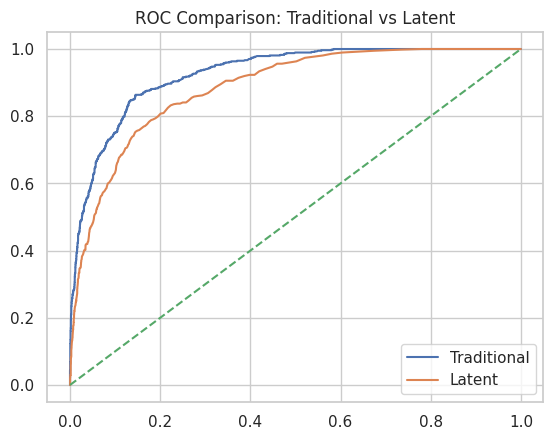

In [ ]:
# Traditional best model
best_model_name = max(traditional_auc_scores, key=traditional_auc_scores.get)
best_trad_probs = trained_models[best_model_name].predict_proba(X_test)[:,1]

fpr_trad, tpr_trad, _ = roc_curve(y_test, best_trad_probs)
fpr_lat, tpr_lat, _ = roc_curve(y_test, probs_latent)

plt.figure()
plt.plot(fpr_trad, tpr_trad, label="Traditional")
plt.plot(fpr_lat, tpr_lat, label="Latent")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Comparison: Traditional vs Latent")
plt.show()

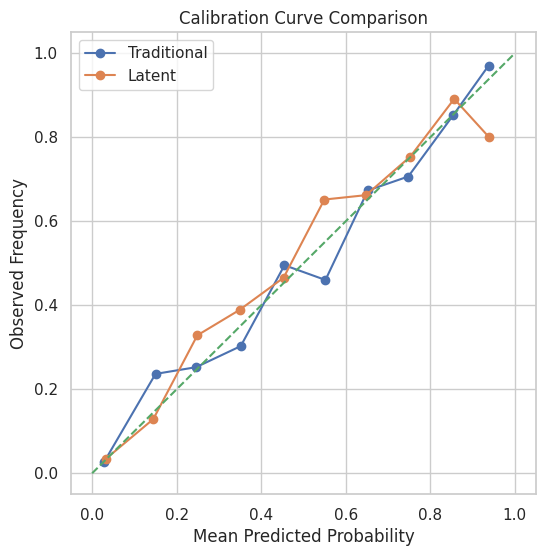

Traditional Brier Score: 0.07190674769840087
Latent Brier Score: 0.08723810339130697


In [ ]:
# -------------------------------------------
# Calibration Comparison
# -------------------------------------------

prob_true_trad, prob_pred_trad = calibration_curve(
    y_test, best_trad_probs, n_bins=10
)

prob_true_lat, prob_pred_lat = calibration_curve(
    y_test, probs_latent, n_bins=10
)

plt.figure(figsize=(6,6))
plt.plot(prob_pred_trad, prob_true_trad, marker="o", label="Traditional")
plt.plot(prob_pred_lat, prob_true_lat, marker="o", label="Latent")
plt.plot([0,1],[0,1],'--')
plt.title("Calibration Curve Comparison")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Frequency")
plt.legend()
plt.show()

print("Traditional Brier Score:", brier_score_loss(y_test, best_trad_probs))
print("Latent Brier Score:", brier_score_loss(y_test, probs_latent))

Interpretation:

- The closer the curve is to the diagonal, the better calibrated the model.
- Lower Brier Score indicates better probability reliability.

Improved calibration in the latent model would indicate that the compressed behavioural representation captures meaningful probabilistic structure.

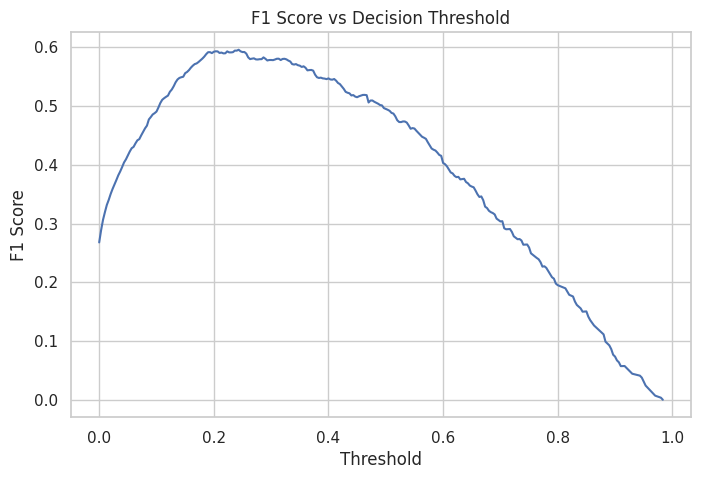

Optimal Threshold: 0.24333333333333335


In [ ]:
# -------------------------------------------
# Threshold Optimisation (Latent Model)
# -------------------------------------------

precision, recall, thresholds = precision_recall_curve(y_test, probs_latent)
f1_scores = 2*(precision*recall)/(precision+recall+1e-8)

plt.figure(figsize=(8,5))
plt.plot(thresholds, f1_scores[:-1])
plt.title("F1 Score vs Decision Threshold")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.show()

optimal_threshold = thresholds[np.argmax(f1_scores[:-1])]
print("Optimal Threshold:", optimal_threshold)

Interpretation:

The optimal threshold maximises F1 score,
balancing Precision and Recall.

This is especially important in e-commerce settings where:
- False negatives mean missed buyers.
- False positives increase marketing costs.

## 4.8 Behavioural Error Diagnostics

Beyond overall accuracy, examining misclassifications provides deeper insight into behavioural ambiguity.

This section analyses:

- False Negatives (missed buyers)
- False Positives (misclassified non-buyers)

This supports behavioural interpretation and business improvement.

In [ ]:
# ---------------------------------------------------
# Generate Final Predictions Using Optimal Threshold
# ---------------------------------------------------

# Convert probabilities into class labels using optimised threshold
final_preds = (probs_latent >= optimal_threshold).astype(int)

In [ ]:
# ---------------------------------------------------
# Create Error Analysis Dataset
# ---------------------------------------------------

# Copy test feature set to preserve original behavioural variables
error_df = X_test.copy()

# Add actual and predicted labels
error_df["Actual"] = y_test.values
error_df["Predicted"] = final_preds

# Initialise all rows as correct predictions
error_df["Error Type"] = "Correct"

In [ ]:
# ---------------------------------------------------
# Assign False Negative and False Positive Labels
# ---------------------------------------------------

# False Negative: Buyer predicted as non-buyer
error_df.loc[
    (error_df["Actual"] == 1) & (error_df["Predicted"] == 0),
    "Error Type"
] = "False Negative"

# False Positive: Non-buyer predicted as buyer
error_df.loc[
    (error_df["Actual"] == 0) & (error_df["Predicted"] == 1),
    "Error Type"
] = "False Positive"

# Verify counts
print(error_df["Error Type"].value_counts())

Error Type
Correct           3174
False Positive     340
False Negative     185
Name: count, dtype: int64


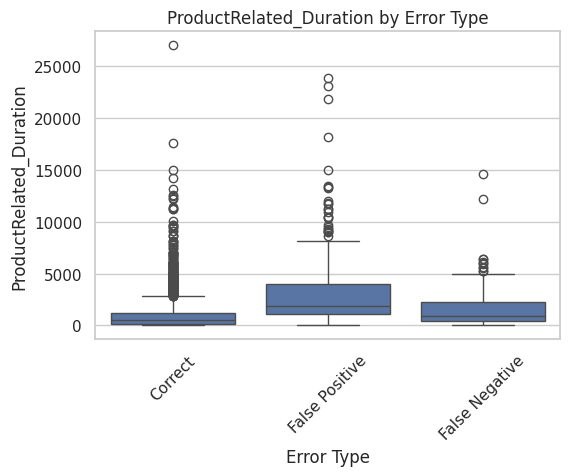

In [ ]:
# ---------------------------------------------------
# Engagement Duration by Error Type
# ---------------------------------------------------

plt.figure(figsize=(6,4))
sns.boxplot(
    x="Error Type",
    y="ProductRelated_Duration",
    data=error_df
)
plt.xticks(rotation=45)
plt.title("ProductRelated_Duration by Error Type")
plt.show()

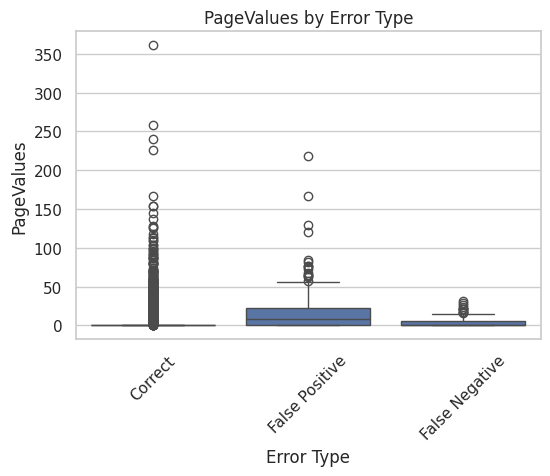

In [ ]:
# ---------------------------------------------------
# PageValues by Error Type
# ---------------------------------------------------

plt.figure(figsize=(6,4))
sns.boxplot(
    x="Error Type",
    y="PageValues",
    data=error_df
)
plt.xticks(rotation=45)
plt.title("PageValues by Error Type")
plt.show()

In [ ]:
# ---------------------------------------------------
# Numerical Behavioural Summary by Error Type
# ---------------------------------------------------

error_summary = error_df.groupby("Error Type")[[
    "ProductRelated_Duration",
    "PageValues",
    "BounceRates",
    "ExitRates"
]].mean()

print(error_summary)

                ProductRelated_Duration  PageValues  BounceRates  ExitRates
Error Type                                                                 
Correct                     1009.091356    4.751527     0.024924   0.046327
False Negative              1660.309146    3.808971     0.008798   0.027625
False Positive              3110.518663   15.755859     0.007691   0.021850


These borderline cases indicate that purchase intention is not strictly binary but often reflects gradual behavioural transitions
Interpretation:

False Negatives often show moderate engagement levels.
These sessions lie in behavioural ambiguity zones.

This suggests:
- Hybrid modelling or additional features may improve classification.
- Behavioural transitions are gradual rather than binary.

## 4.9 Business Simulation

A practical marketing scenario is simulated:

If only the top 20% highest probability sessions are targeted,
what percentage of true buyers would be captured?

This evaluates real-world targeting efficiency.

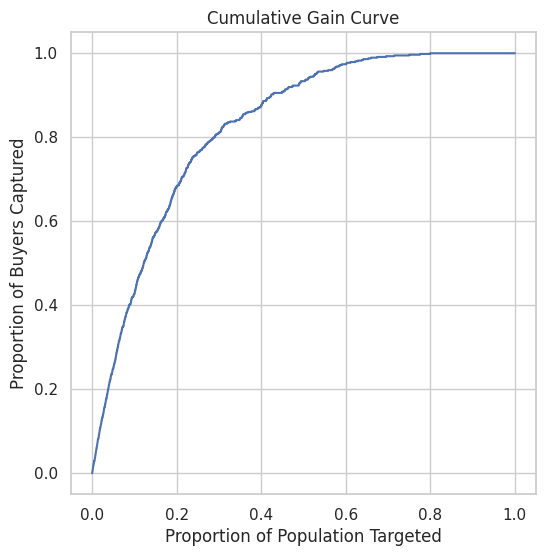

In [ ]:
sorted_indices = np.argsort(probs_latent)[::-1]
sorted_actual = y_test.values[sorted_indices]

cumulative_buyers = np.cumsum(sorted_actual)
total_buyers = sorted_actual.sum()

percentage_population = np.arange(1,len(sorted_actual)+1)/len(sorted_actual)
buyer_capture_rate = cumulative_buyers/total_buyers

plt.figure(figsize=(6,6))
plt.plot(percentage_population, buyer_capture_rate)
plt.title("Cumulative Gain Curve")
plt.xlabel("Proportion of Population Targeted")
plt.ylabel("Proportion of Buyers Captured")
plt.show()

In [ ]:
top_20_threshold = np.percentile(probs_latent, 80)
selected = probs_latent >= top_20_threshold

captured = y_test[selected].sum()
recall_top20 = captured / total_buyers

print("Recall when targeting top 20% sessions:", recall_top20)

Recall when targeting top 20% sessions: 0.6853146853146853


Interpretation:

If a relatively small proportion of high-scoring sessions captures a substantial share of buyers, the model demonstrates practical value for targeted marketing strategies

This demonstrates the practical utility of predictive modelling
beyond statistical performance.

In [ ]:
# ---------------------------------------
# 4.10 Hybrid Feature Integration Model
# ---------------------------------------

import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Step 1: Transform engineered features explicitly
X_train_engineered = preprocessor.fit_transform(X_train)
X_test_engineered = preprocessor.transform(X_test)

# Step 2: Latent features already created earlier
# (Make sure these exist: X_train_latent, X_test_latent)

# Step 3: Combine engineered + latent
X_hybrid_train = np.hstack([X_train_engineered, X_train_latent])
X_hybrid_test = np.hstack([X_test_engineered, X_test_latent])

# Step 4: Train Gradient Boosting
hybrid_model = GradientBoostingClassifier(random_state=42)
hybrid_model.fit(X_hybrid_train, y_train)

# Step 5: Predictions
hybrid_preds = hybrid_model.predict(X_hybrid_test)
hybrid_probs = hybrid_model.predict_proba(X_hybrid_test)[:, 1]

# Step 6: Evaluation
print("Hybrid Model Performance")
print(classification_report(y_test, hybrid_preds))
print("Hybrid ROC-AUC:", roc_auc_score(y_test, hybrid_probs))
print("Confusion Matrix:\n", confusion_matrix(y_test, hybrid_preds))

Hybrid Model Performance
              precision    recall  f1-score   support

           0       0.92      0.95      0.94      3127
           1       0.70      0.58      0.63       572

    accuracy                           0.90      3699
   macro avg       0.81      0.77      0.79      3699
weighted avg       0.89      0.90      0.89      3699

Hybrid ROC-AUC: 0.9220957328568458
Confusion Matrix:
 [[2984  143]
 [ 242  330]]


In [ ]:
# ==========================================================
# APPENDIX MASTER EXTRACTION SCRIPT
# Run after all models are trained
# ==========================================================

import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score,
    brier_score_loss
)

print("\n==============================")
print("APPENDIX B – FEATURE NAMES")
print("==============================")

feature_names = preprocessor.get_feature_names_out()
feature_df = pd.DataFrame({
    "Feature Number": range(1, len(feature_names)+1),
    "Feature Name": feature_names
})
print(feature_df)
feature_df.to_csv("APPENDIX_B_Feature_List.csv", index=False)


# ==========================================================
print("\n==============================")
print("APPENDIX C – STABILITY SUMMARY")
print("==============================")

print(stability_df)
stability_df.to_csv("APPENDIX_C_Seed_Level_Results.csv", index=False)

print("\nStability Summary (Mean + Std)")
print(stability_summary)
stability_summary.to_csv("APPENDIX_C_Model_Stability_Summary.csv")


# ==========================================================
print("\n==============================")
print("APPENDIX D – THRESHOLD GRID (LATENT)")
print("==============================")

precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, probs_latent)

threshold_table = pd.DataFrame({
    "Threshold": thresholds,
    "Precision": precision_vals[:-1],
    "Recall": recall_vals[:-1],
})

threshold_table["F1"] = 2 * (
    threshold_table["Precision"] * threshold_table["Recall"]
) / (
    threshold_table["Precision"] + threshold_table["Recall"] + 1e-8
)

print(threshold_table.head())
threshold_table.to_csv("APPENDIX_D_Threshold_Grid.csv", index=False)


# ==========================================================
print("\n==============================")
print("APPENDIX E – AUTOENCODER LOSS")
print("==============================")

loss_df = pd.DataFrame({
    "Epoch": range(1, len(history.history["loss"]) + 1),
    "Train Loss": history.history["loss"],
    "Validation Loss": history.history["val_loss"]
})

print(loss_df.head())
loss_df.to_csv("APPENDIX_E_Autoencoder_Loss.csv", index=False)


# ==========================================================
print("\n==============================")
print("APPENDIX F – HYBRID MODEL SUMMARY")
print("==============================")

hybrid_summary = {
    "Accuracy": accuracy_score(y_test, hybrid_preds),
    "Precision": precision_score(y_test, hybrid_preds),
    "Recall": recall_score(y_test, hybrid_preds),
    "F1 Score": f1_score(y_test, hybrid_preds),
    "ROC-AUC": roc_auc_score(y_test, hybrid_probs)
}

hybrid_df = pd.DataFrame([hybrid_summary])
print(hybrid_df)
hybrid_df.to_csv("APPENDIX_F_Hybrid_Performance.csv", index=False)


# ==========================================================
print("\n==============================")
print("APPENDIX I – CONFUSION MATRICES")
print("==============================")

confusion_tables = []

for name, model in trained_models.items():
    preds = model.predict(X_test)
    cm = confusion_matrix(y_test, preds)

    cm_df = pd.DataFrame(cm,
                         index=["Actual_0","Actual_1"],
                         columns=["Pred_0","Pred_1"])

    print(f"\n{name}")
    print(cm_df)

    cm_df.to_csv(f"APPENDIX_I_CM_{name.replace(' ','_')}.csv")

    confusion_tables.append((name, cm_df))


# Hybrid confusion matrix
hybrid_cm = confusion_matrix(y_test, hybrid_preds)
hybrid_cm_df = pd.DataFrame(hybrid_cm,
                            index=["Actual_0","Actual_1"],
                            columns=["Pred_0","Pred_1"])
print("\nHybrid Model")
print(hybrid_cm_df)
hybrid_cm_df.to_csv("APPENDIX_I_CM_Hybrid.csv")


# ==========================================================
print("\n==============================")
print("APPENDIX K – CALIBRATION TABLE")
print("==============================")

calibration_table = pd.DataFrame({
    "Model": ["Traditional_Best", "Latent"],
    "Brier Score": [
        brier_score_loss(y_test, best_trad_probs),
        brier_score_loss(y_test, probs_latent)
    ]
})

print(calibration_table)
calibration_table.to_csv("APPENDIX_K_Calibration.csv", index=False)


# ==========================================================
print("\n==============================")
print("APPENDIX G – LIFT / DECILE TABLE")
print("==============================")

lift_df = pd.DataFrame({
    "Probability": probs_latent,
    "Actual": y_test.values
}).sort_values("Probability", ascending=False)

lift_df["Decile"] = pd.qcut(
    np.arange(len(lift_df)),
    10,
    labels=False
)

decile_table = lift_df.groupby("Decile")["Actual"].agg(
    ["count", "sum"]
).reset_index()

decile_table["Conversion Rate"] = decile_table["sum"] / decile_table["count"]

print(decile_table)
decile_table.to_csv("APPENDIX_G_Decile_Table.csv", index=False)


print("\n======================================")
print("ALL APPENDIX TABLES EXPORTED SUCCESSFULLY")
print("Check your working directory.")
print("======================================")


APPENDIX B – FEATURE NAMES
    Feature Number                        Feature Name
0                1                 num__Administrative
1                2        num__Administrative_Duration
2                3                  num__Informational
3                4         num__Informational_Duration
4                5                 num__ProductRelated
5                6        num__ProductRelated_Duration
6                7                    num__BounceRates
7                8                      num__ExitRates
8                9                     num__PageValues
9               10                     num__SpecialDay
10              11               num__OperatingSystems
11              12                        num__Browser
12              13                         num__Region
13              14                    num__TrafficType
14              15                      cat__Month_Aug
15              16                      cat__Month_Dec
16              17                   